In [110]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [111]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 8, 'axis': 'z'}

In [112]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test8/rolling_z
['reference', 'info.json', 'target']


In [113]:
TARGET_VAR = 'roll'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [15, 60], 'static': [65, 999999999]}
[65, 999999999]
[15, 60]


# IMPORTANDO DADOS

In [114]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,pitch,e,ay,roll,yaw,ax,wy,time,az,wz,wx,tmp
0,-3504,0.576,-75875,-66,1102,10122,7402,2.384186e-07,1003109,844,-26278,48.6
1,-3535,0.576,-50796,-86,1122,405,21293,8.465290e-02,994472,6776,1305,48.4
2,-3512,0.576,-65415,-75,1127,6331,-13272,1.922421e-01,1003720,694,-4798,48.7
3,-3533,0.576,-61509,-87,1132,7642,8147,2.940345e-01,989252,-5734,-54905,48.5
4,-3518,0.576,-59611,-78,1134,1672,13078,3.834641e-01,1000142,8645,10647,48.7
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,-3639,1.656,-68334,-89,2023,-8019,-38208,1.033927e+02,989699,-14148,3454,51.1
1035,-3634,1.656,-43882,-94,2022,-3091,6300,1.034937e+02,995739,6471,-5436,51.1
1036,-3628,1.656,-65842,-97,2024,-5972,21442,1.035909e+02,997091,-6451,35328,51.0
1037,-3626,1.656,-40408,-100,2026,7952,4251,1.036941e+02,990678,31530,15344,50.9


- Convertendo pra radianos

In [115]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,pitch,e,ay,roll,yaw,ax,wy,time,az,wz,wx,tmp
0,-3.504,0.576,-0.744080,-0.066,1.102,0.099263,0.07402,2.384186e-07,9.837139,0.00844,-0.26278,48.6
1,-3.535,0.576,-0.498139,-0.086,1.122,0.003972,0.21293,8.465290e-02,9.752439,0.06776,0.01305,48.4
2,-3.512,0.576,-0.641502,-0.075,1.127,0.062086,-0.13272,1.922421e-01,9.843131,0.00694,-0.04798,48.7
3,-3.533,0.576,-0.603197,-0.087,1.132,0.074942,0.08147,2.940345e-01,9.701248,-0.05734,-0.54905,48.5
4,-3.518,0.576,-0.584584,-0.078,1.134,0.016397,0.13078,3.834641e-01,9.808043,0.08645,0.10647,48.7


- Formatando as colunas pra ficar igual a de referência

In [116]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,pitch,e,ay,roll,yaw,ax,wy,time,az,wz,wx,tmp
0,0.066,0.576,9.837139,-3.504,1.102,0.099263,-0.00844,2.384186e-07,-0.744080,0.07402,-0.26278,48.6
1,0.086,0.576,9.752439,-3.535,1.122,0.003972,-0.06776,8.465290e-02,-0.498139,0.21293,0.01305,48.4
2,0.075,0.576,9.843131,-3.512,1.127,0.062086,-0.00694,1.922421e-01,-0.641502,-0.13272,-0.04798,48.7
3,0.087,0.576,9.701248,-3.533,1.132,0.074942,0.05734,2.940345e-01,-0.603197,0.08147,-0.54905,48.5
4,0.078,0.576,9.808043,-3.518,1.134,0.016397,-0.08645,3.834641e-01,-0.584584,0.13078,0.10647,48.7


In [117]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,pitch,e,ay,roll,yaw,ax,wy,time,az,wz,wx,tmp


# VISUALIZAÇÃO DE VARIÁVEIS

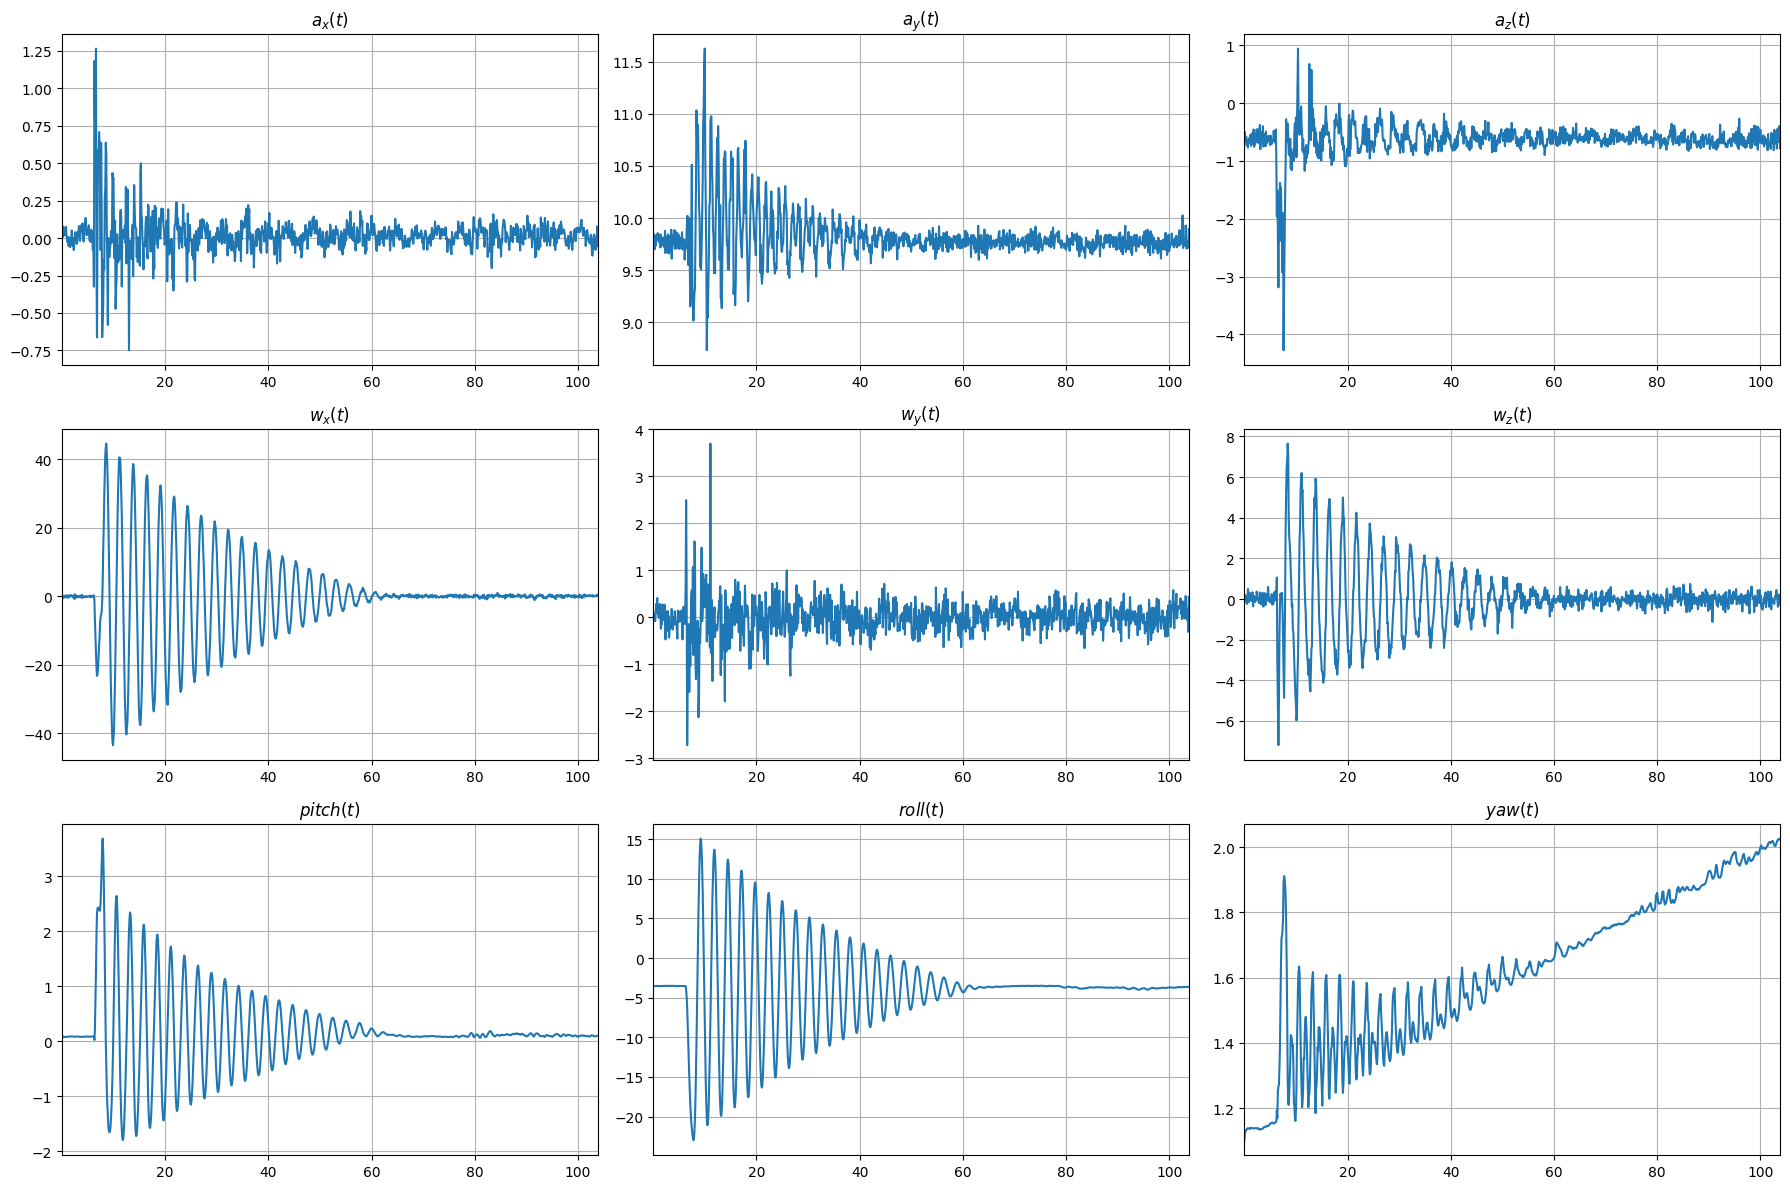

In [118]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

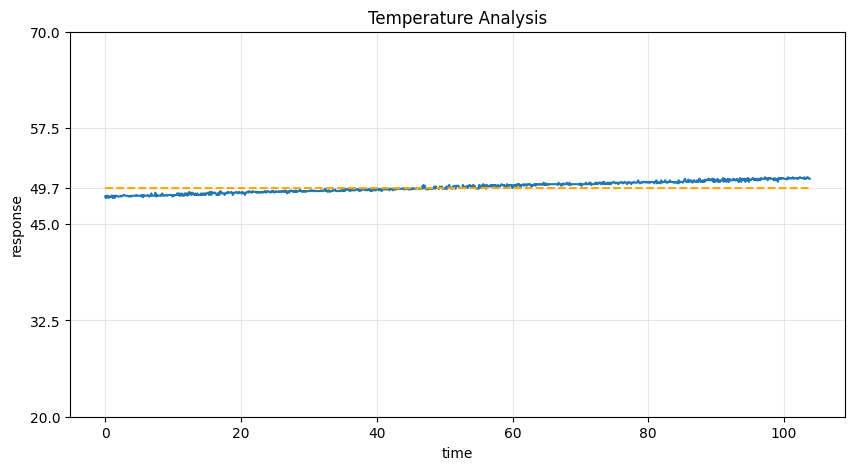

In [119]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

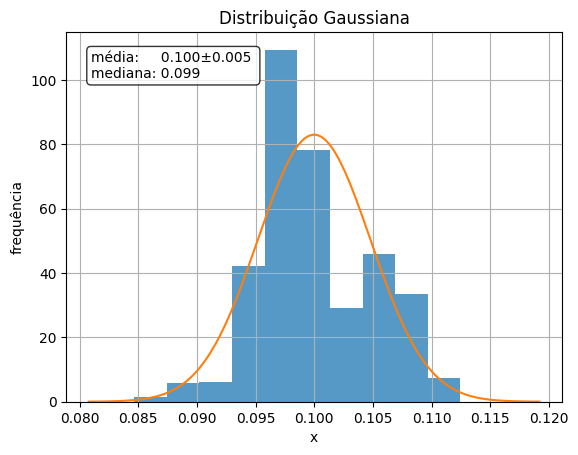

,time,pitch,e,ay,roll,yaw,ax,wy,az,wz,wx,tmp
0,0.0,0.066,0.576,9.837139,-3.504,1.102,0.099263,-0.00844,-0.744080,0.07402,-0.26278,48.6
1,0.1,0.086,0.576,9.752439,-3.535,1.122,0.003972,-0.06776,-0.498139,0.21293,0.01305,48.4
2,0.2,0.075,0.576,9.843131,-3.512,1.127,0.062086,-0.00694,-0.641502,-0.13272,-0.04798,48.7
3,0.3,0.087,0.576,9.701248,-3.533,1.132,0.074942,0.05734,-0.603197,0.08147,-0.54905,48.5
4,0.4,0.078,0.576,9.808043,-3.518,1.134,0.016397,-0.08645,-0.584584,0.13078,0.10647,48.7
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,103.4,0.089,1.656,9.705632,-3.639,2.023,-0.078640,0.14148,-0.670128,-0.38208,0.03454,51.1
1035,103.5,0.094,1.656,9.764864,-3.634,2.022,-0.030312,-0.06471,-0.430335,0.06300,-0.05436,51.1
1036,103.6,0.097,1.656,9.778122,-3.628,2.024,-0.058565,0.06451,-0.645689,0.21442,0.35328,51.0
1037,103.7,0.100,1.656,9.715232,-3.626,2.026,0.077982,-0.31530,-0.396267,0.04251,0.15344,50.9


In [120]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [121]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [122]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,pitch,e,ay,roll,yaw,ax,wy,az,wz,wx,tmp,static
0,0.0,-0.121,1.260,10.637460,-1.169,1.208,-0.184816,-0.20151,-0.442486,-3.57567,-37.17227,49.1,False
1,0.1,0.242,1.224,10.448299,-4.909,1.284,0.439397,0.27387,-0.823160,-3.70565,-37.66696,49.0,False
2,0.2,0.617,1.152,10.444965,-8.549,1.303,0.498737,-0.44279,-0.387922,-4.11628,-35.36233,48.8,False
3,0.3,1.002,1.116,10.572579,-11.886,1.351,0.160594,0.19496,-0.588644,-3.79309,-31.62409,49.2,False
4,0.4,1.367,1.116,10.269612,-14.729,1.419,0.133920,0.42812,-0.450782,-3.84595,-26.66659,49.1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.089,1.656,9.705632,-3.639,2.023,-0.078640,0.14148,-0.670128,-0.38208,0.03454,51.1,True
835,83.4,0.094,1.656,9.764864,-3.634,2.022,-0.030312,-0.06471,-0.430335,0.06300,-0.05436,51.1,True
836,83.5,0.097,1.656,9.778122,-3.628,2.024,-0.058565,0.06451,-0.645689,0.21442,0.35328,51.0,True
837,83.6,0.100,1.656,9.715232,-3.626,2.026,0.077982,-0.31530,-0.396267,0.04251,0.15344,50.9,True


# FILTRANDO POR VARIAVEL

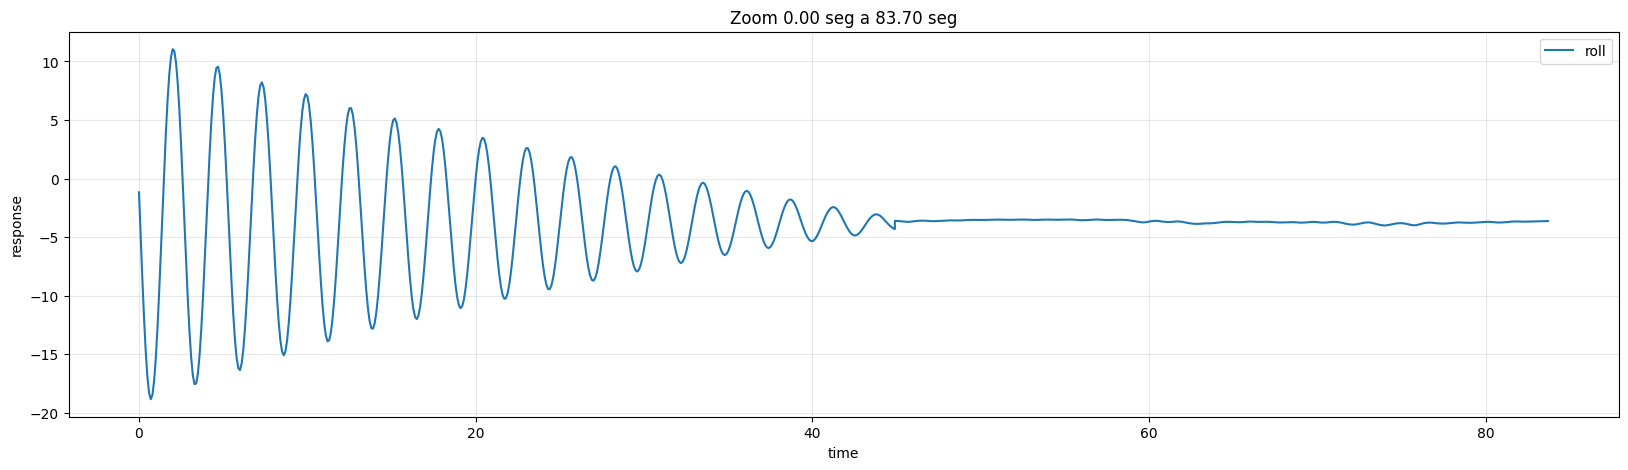

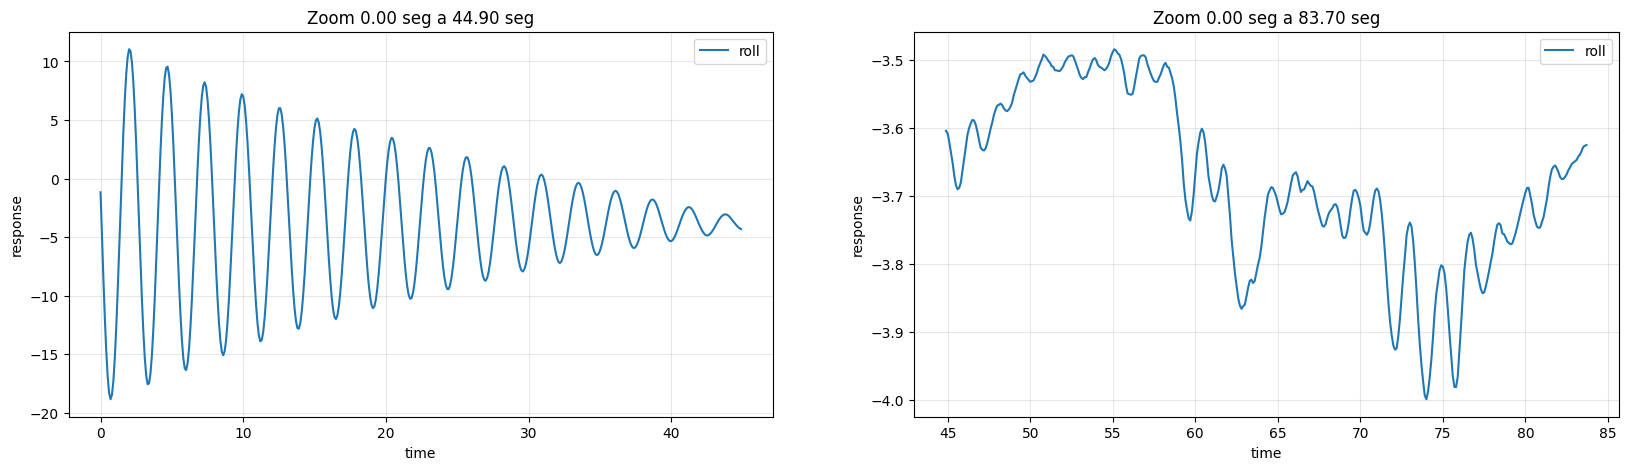

In [123]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [124]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_pitch,target_e,target_ay,target_roll,target_yaw,target_ax,target_wy,target_az,target_wz,target_wx,target_tmp,static
0,0.0,-0.121,1.260,10.637460,-1.169,1.208,-0.184816,-0.20151,-0.442486,-3.57567,-37.17227,49.1,False
1,0.1,0.242,1.224,10.448299,-4.909,1.284,0.439397,0.27387,-0.823160,-3.70565,-37.66696,49.0,False
2,0.2,0.617,1.152,10.444965,-8.549,1.303,0.498737,-0.44279,-0.387922,-4.11628,-35.36233,48.8,False
3,0.3,1.002,1.116,10.572579,-11.886,1.351,0.160594,0.19496,-0.588644,-3.79309,-31.62409,49.2,False
4,0.4,1.367,1.116,10.269612,-14.729,1.419,0.133920,0.42812,-0.450782,-3.84595,-26.66659,49.1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,83.3,0.089,1.656,9.705632,-3.639,2.023,-0.078640,0.14148,-0.670128,-0.38208,0.03454,51.1,True
835,83.4,0.094,1.656,9.764864,-3.634,2.022,-0.030312,-0.06471,-0.430335,0.06300,-0.05436,51.1,True
836,83.5,0.097,1.656,9.778122,-3.628,2.024,-0.058565,0.06451,-0.645689,0.21442,0.35328,51.0,True
837,83.6,0.100,1.656,9.715232,-3.626,2.026,0.077982,-0.31530,-0.396267,0.04251,0.15344,50.9,True


In [125]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)